# Steam Genre Co-occurrence Network Analysis

**research question:** how do game genres connect in the steam ecosystem, and can network structure predict a game's market positioning?

**dataset:** steam dataset 2025 (239,664 applications)


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import defaultdict, Counter
from itertools import combinations
from networkx.algorithms.community import greedy_modularity_communities
import re
import random
import warnings
warnings.filterwarnings('ignore')

## 1. load data

In [32]:
DATA_DIR = r"C:\Users\WINDOWS\Desktop\dm\data"

apps = pd.read_csv(f"{DATA_DIR}/applications.csv")
app_genres = pd.read_csv(f"{DATA_DIR}/application_genres.csv")
genres_meta = pd.read_csv(f"{DATA_DIR}/genres.csv")

print(f"applications: {len(apps):,}")
print(f"app-genre pairs: {len(app_genres):,}")
print(f"genre entries: {len(genres_meta)}")
apps.head(3)

applications: 239,664
app-genre pairs: 587,515
genre entries: 154


,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,...,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
0,10,Counter-Strike,game,False,2000-11-01,0,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,False,1999-04-01,0,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,False,2003-05-01,0,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


## 2. filter english genres

In [33]:
english_genres = {
    5: 'Strategy', 11: 'Simulation', 12: 'Sexual Content',
    15: 'Racing', 16: 'Massively Multiplayer', 23: 'Episodic',
    31: 'Indie', 32: 'Casual', 44: 'Free To Play',
    49: 'Nudity', 62: 'Sports', 79: 'Gore',
    93: 'Free To Play', 106: 'Violent', 107: 'Early Access',
    113: 'Adventure', 122: 'Action', 144: 'RPG', 151: 'Short'
}

genre_id_to_name = english_genres

app_genres_en = app_genres[app_genres['genre_id'].isin(genre_id_to_name.keys())].copy()
app_genres_en['genre_name'] = app_genres_en['genre_id'].map(genre_id_to_name)

print(f"app-genre pairs (english only): {len(app_genres_en):,}")
print(f"unique english genres: {app_genres_en['genre_name'].nunique()}")

app-genre pairs (english only): 570,242
unique english genres: 18


## 3. filter to games

In [34]:
game_apps = apps[apps['type'] == 'game']['appid'].values
app_genres_games = app_genres_en[app_genres_en['appid'].isin(game_apps)].copy()

print(f"app-genre pairs (games only): {len(app_genres_games):,}")
print(f"genres remaining: {app_genres_games['genre_name'].nunique()}")
print(f"games covered: {app_genres_games['appid'].nunique():,}")

app-genre pairs (games only): 409,943
genres remaining: 18
games covered: 141,276


## 4. build genre co-occurrence network

In [35]:
game_genre_groups = app_genres_games.groupby('appid')['genre_name'].apply(list).reset_index()

edge_weights = defaultdict(int)
genre_game_count = defaultdict(int)

for _, row in game_genre_groups.iterrows():
    unique_genres = list(set(row['genre_name']))
    for g in unique_genres:
        genre_game_count[g] += 1
    for g1, g2 in combinations(sorted(unique_genres), 2):
        edge_weights[(g1, g2)] += 1

G = nx.Graph()
for genre, count in genre_game_count.items():
    G.add_node(genre, game_count=count)
for (g1, g2), weight in edge_weights.items():
    G.add_edge(g1, g2, weight=weight)

print(f"nodes (genres): {G.number_of_nodes()}")
print(f"edges (co-occurrence pairs): {G.number_of_edges()}")
print(f"\ngames per genre:")
for genre in sorted(genre_game_count, key=genre_game_count.get, reverse=True):
    print(f"  {genre:<25s}: {genre_game_count[genre]:>6,}")

nodes (genres): 18
edges (co-occurrence pairs): 125

games per genre:
  Indie                    : 101,199
  Action                   : 60,431
  Adventure                : 59,014
  Casual                   : 58,458
  Simulation               : 30,321
  Strategy                 : 28,648
  RPG                      : 28,490
  Early Access             : 14,603
  Free To Play             : 13,724
  Sports                   :  5,533
  Racing                   :  4,947
  Massively Multiplayer    :  3,649
  Violent                  :    453
  Gore                     :    277
  Nudity                   :    100
  Sexual Content           :     94
  Short                    :      1
  Episodic                 :      1


## 5. centrality analysis

In [36]:
degree_dict = dict(G.degree(weight='weight'))
betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)
closeness = nx.closeness_centrality(G, distance=None)
pagerank = nx.pagerank(G, weight='weight')

metrics_df = pd.DataFrame({
    'genre': list(G.nodes()),
    'game_count': [G.nodes[n]['game_count'] for n in G.nodes()],
    'weighted_degree': [degree_dict[n] for n in G.nodes()],
    'betweenness': [betweenness[n] for n in G.nodes()],
    'closeness': [closeness[n] for n in G.nodes()],
    'pagerank': [pagerank[n] for n in G.nodes()]
})
metrics_df = metrics_df.sort_values('pagerank', ascending=False).reset_index(drop=True)

print("genre centrality metrics (sorted by pagerank):")
metrics_df

genre centrality metrics (sorted by pagerank):


,genre,game_count,weighted_degree,betweenness,closeness,pagerank
0,Indie,101199,227691,0.000000,1.000000,0.197290
1,Casual,58458,139265,0.308824,1.000000,0.124554
2,Adventure,59014,145553,0.000000,0.894737,0.124455
3,Action,60431,143226,0.000000,0.894737,0.123993
4,Simulation,30321,82896,0.000000,0.894737,0.074607
5,RPG,28490,81246,0.000000,0.894737,0.072280
6,Strategy,28648,75996,0.000000,0.894737,0.067607
7,Early Access,14603,45092,0.000000,0.894737,0.044350
8,Free To Play,13724,38587,0.000000,0.894737,0.038935
9,Sports,5533,18249,0.094363,0.894737,0.022997


## 6. community detection

In [37]:
communities = list(greedy_modularity_communities(G, weight='weight'))

community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

print(f"communities found: {len(communities)}")
for i, comm in enumerate(communities):
    print(f"  community {i+1}: {sorted(comm)}")

communities found: 5
  community 1: ['Action', 'Adventure', 'Casual', 'Early Access', 'Indie', 'RPG', 'Simulation', 'Strategy']
  community 2: ['Gore', 'Nudity', 'Sexual Content', 'Violent']
  community 3: ['Free To Play', 'Massively Multiplayer']
  community 4: ['Racing', 'Sports']
  community 5: ['Episodic', 'Short']


## 7. game co-occurrence network

Each node is a sampled game. Two games are connected if they share 2 or more genre tags. Node color represents the primary genre, node size represents degree.

snowball sampled 500 games
nodes: 500, edges: 58088


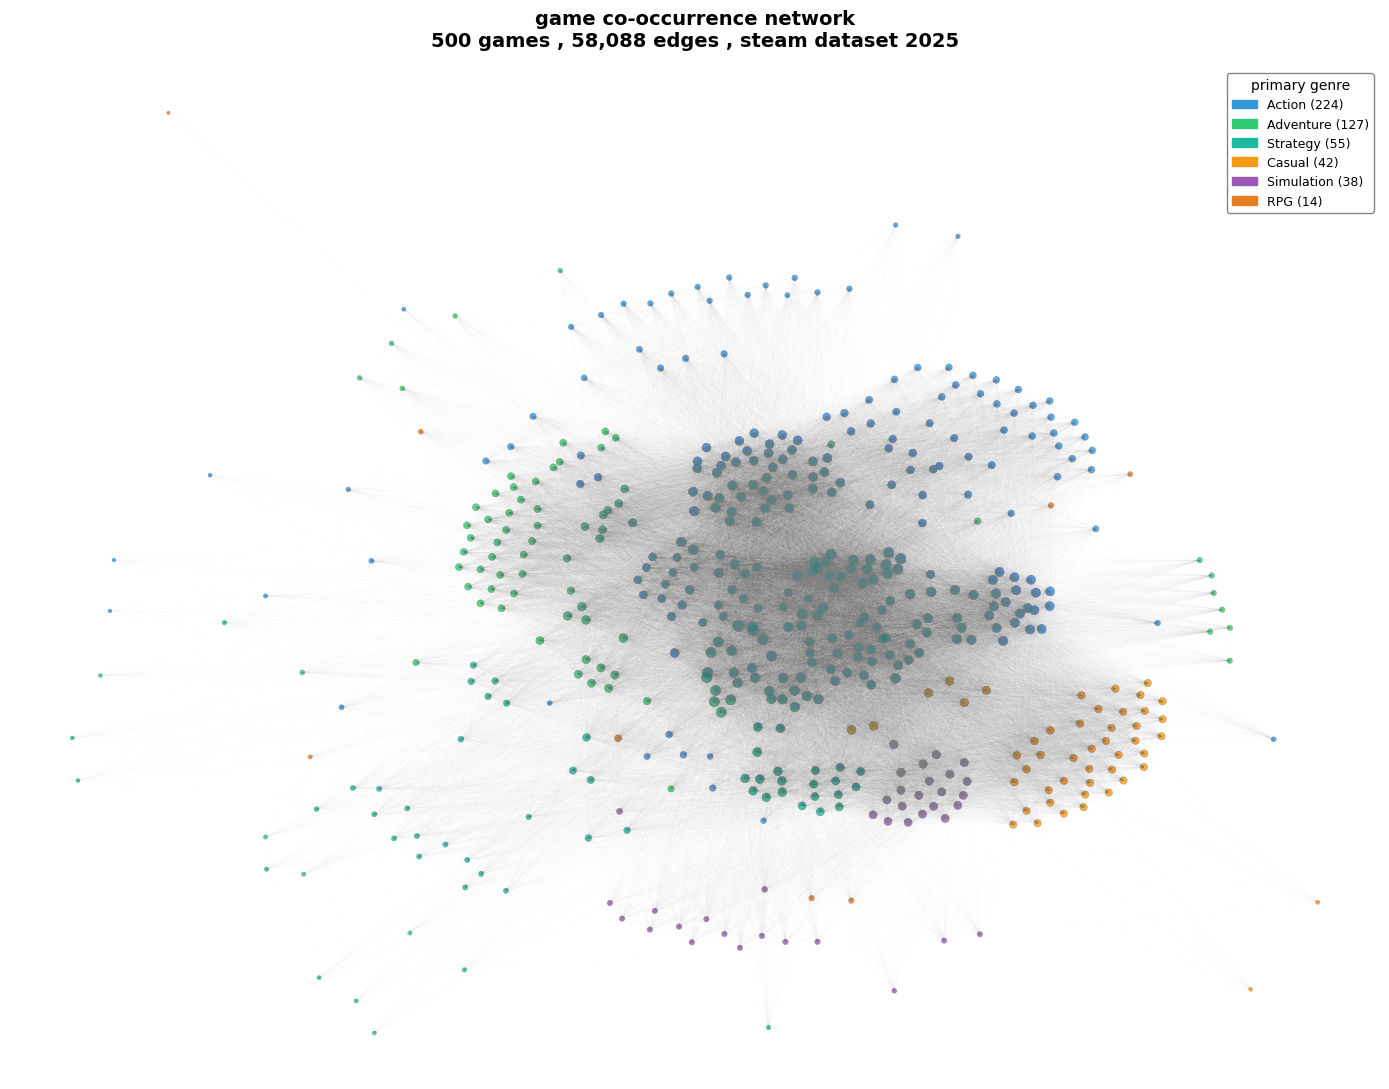

In [38]:
random.seed(42)

top_genre_list = ['Action', 'Adventure', 'Strategy', 'RPG', 'Simulation',
                  'Casual', 'Sports', 'Racing', 'Free To Play',
                  'Early Access', 'Massively Multiplayer', 'Indie']

genre_color_map = {
    'Action': '#3498DB', 'Adventure': '#2ECC71', 'Strategy': '#1ABC9C',
    'RPG': '#E67E22', 'Simulation': '#9B59B6', 'Casual': '#F39C12',
    'Sports': '#34495E', 'Racing': '#D35400', 'Free To Play': '#27AE60',
    'Early Access': '#C0392B', 'Massively Multiplayer': '#2980B9',
    'Indie': '#E74C3C'
}

def get_primary(genres):
    for g in top_genre_list:
        if g in genres:
            return g
    return list(genres)[0]

game_groups = app_genres_games.groupby('appid')['genre_name'].apply(set).reset_index()
game_groups = game_groups[game_groups['genre_name'].apply(len) >= 2].reset_index(drop=True)
all_dict = dict(zip(game_groups['appid'], game_groups['genre_name']))
all_ids = list(all_dict.keys())

pool_size = 3000
pool_ids = random.sample(all_ids, min(pool_size, len(all_ids)))

from collections import defaultdict

adjacency = defaultdict(list)
for i in range(len(pool_ids)):
    for j in range(i+1, len(pool_ids)):
        a, b = pool_ids[i], pool_ids[j]
        shared = all_dict[a] & all_dict[b]
        if len(shared) >= 2:
            adjacency[a].append(b)
            adjacency[b].append(a)

seed_node = max(adjacency, key=lambda x: len(adjacency[x]))
TARGET_N = 500

visited = {seed_node}
frontier = [seed_node]

while frontier and len(visited) < TARGET_N:
    u = frontier.pop(0)
    for v in adjacency[u]:
        if v not in visited:
            visited.add(v)
            frontier.append(v)
            if len(visited) >= TARGET_N:
                break

sampled_ids = list(visited)
print(f"snowball sampled {len(sampled_ids)} games")

G_games = nx.Graph()
for appid in sampled_ids:
    G_games.add_node(appid)

sampled_set = set(sampled_ids)
for i, a in enumerate(sampled_ids):
    for b in adjacency[a]:
        if b in sampled_set and not G_games.has_edge(a, b):
            shared = all_dict[a] & all_dict[b]
            G_games.add_edge(a, b, weight=len(shared))

print(f"nodes: {G_games.number_of_nodes()}, edges: {G_games.number_of_edges()}")

node_primary = {}
node_colors_games = []
for n in G_games.nodes():
    pg = get_primary(all_dict[n])
    node_primary[n] = pg
    node_colors_games.append(genre_color_map.get(pg, '#95A5A6'))

pos_games = nx.spring_layout(G_games, k=0.12, iterations=50, seed=42)

degrees = dict(G_games.degree())
max_deg = max(degrees.values()) if degrees else 1
node_sizes_games = [5 + 60 * (degrees[n] / max_deg) for n in G_games.nodes()]

fig, ax = plt.subplots(1, 1, figsize=(14, 11))

for (u, v) in G_games.edges():
    xu, yu = pos_games[u]
    xv, yv = pos_games[v]
    ax.plot([xu, xv], [yu, yv], color='gray', alpha=0.02, linewidth=0.2)

xs = [pos_games[n][0] for n in G_games.nodes()]
ys = [pos_games[n][1] for n in G_games.nodes()]
ax.scatter(xs, ys, s=node_sizes_games, c=node_colors_games,
           alpha=0.8, edgecolors='dimgray', linewidths=0.2)

genre_counts = Counter(node_primary.values())
legend_patches = []
for genre in sorted(genre_counts, key=genre_counts.get, reverse=True):
    if genre_counts[genre] >= 5:
        legend_patches.append(
            mpatches.Patch(color=genre_color_map.get(genre, '#95A5A6'),
                           label=f'{genre} ({genre_counts[genre]})'))

ax.legend(handles=legend_patches, loc='upper right', fontsize=9,
          framealpha=0.95, edgecolor='gray', title='primary genre', title_fontsize=10)

ax.set_title(
    'game co-occurrence network\n'
    f'{G_games.number_of_nodes()} games , {G_games.number_of_edges():,} edges , steam dataset 2025',
    fontsize=14, fontweight='bold', pad=15)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/main_figure_game_network.png", dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

## 8. centrality metric correlations

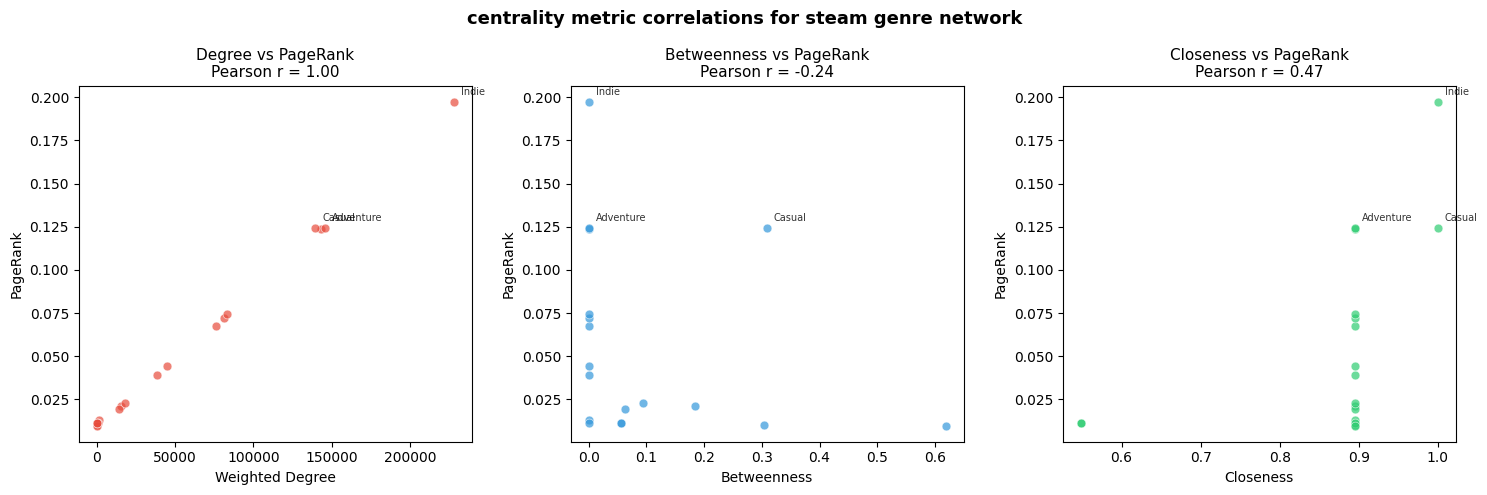

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def scatter_with_corr(ax, x, y, xlabel, title, color, node_names):
    r = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, s=40, alpha=0.7, color=color, edgecolors='white', linewidth=0.5)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('PageRank', fontsize=10)
    ax.set_title(f'{title}\nPearson r = {r:.2f}', fontsize=11)
    top3 = np.argsort(y)[-3:]
    for idx in top3:
        ax.annotate(node_names[idx], (x[idx], y[idx]),
                    fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')

nodes = list(G.nodes())
x_deg = np.array([degree_dict[n] for n in nodes])
x_bet = np.array([betweenness[n] for n in nodes])
x_clo = np.array([closeness[n] for n in nodes])
y_pr = np.array([pagerank[n] for n in nodes])

scatter_with_corr(axes[0], x_deg, y_pr, 'Weighted Degree', 'Degree vs PageRank', '#E74C3C', nodes)
scatter_with_corr(axes[1], x_bet, y_pr, 'Betweenness', 'Betweenness vs PageRank', '#3498DB', nodes)
scatter_with_corr(axes[2], x_clo, y_pr, 'Closeness', 'Closeness vs PageRank', '#2ECC71', nodes)

plt.suptitle('centrality metric correlations for steam genre network',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/centrality_correlations.png", dpi=200, bbox_inches='tight')
plt.show()

## 9. genre trends over time (2010-2025)

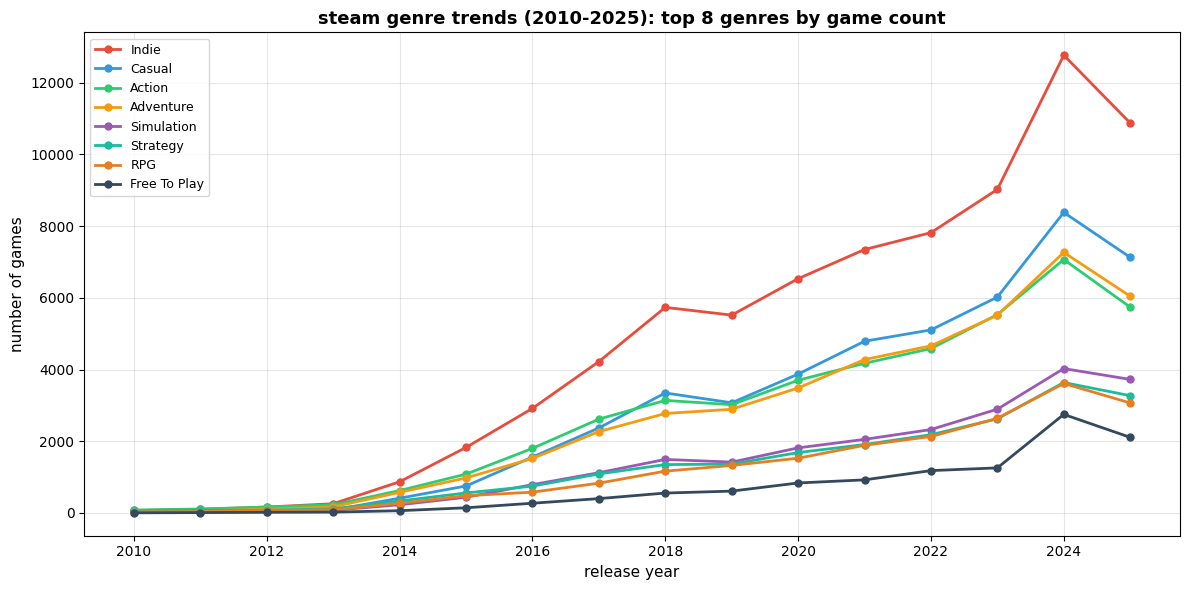

In [40]:
def extract_year(date_str):
    if pd.isna(date_str):
        return np.nan
    m = re.search(r'(\d{4})', str(date_str))
    return int(m.group(1)) if m else np.nan

apps['release_year'] = apps['release_date'].apply(extract_year)

app_genres_time = app_genres_games.merge(
    apps[['appid', 'release_year']], on='appid', how='left')
app_genres_time = app_genres_time[
    app_genres_time['release_year'].between(2010, 2025)].copy()

genre_year_counts = app_genres_time.groupby(
    ['release_year', 'genre_name']
)['appid'].nunique().reset_index(name='game_count')

top_genres_trend = (genre_year_counts.groupby('genre_name')['game_count']
                    .sum().nlargest(8).index.tolist())

fig, ax = plt.subplots(figsize=(12, 6))
colors_trend = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12',
                '#9B59B6', '#1ABC9C', '#E67E22', '#34495E']

for i, genre in enumerate(top_genres_trend):
    gdata = genre_year_counts[genre_year_counts['genre_name'] == genre]
    ax.plot(gdata['release_year'], gdata['game_count'],
            marker='o', linewidth=2, markersize=5,
            color=colors_trend[i], label=genre)

ax.set_xlabel('release year', fontsize=11)
ax.set_ylabel('number of games', fontsize=11)
ax.set_title('steam genre trends (2010-2025): top 8 genres by game count',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/genre_trends.png", dpi=200, bbox_inches='tight')
plt.show()

## 10. prediction: can network features predict game price tier?

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

genre_features = pd.DataFrame({
    'genre_name': list(G.nodes()),
    'genre_pagerank': [pagerank[n] for n in G.nodes()],
    'genre_degree': [degree_dict[n] for n in G.nodes()],
    'genre_betweenness': [betweenness[n] for n in G.nodes()],
    'genre_community': [community_map[n] for n in G.nodes()]
})

app_genre_features = app_genres_games.merge(genre_features, on='genre_name', how='left')

game_net_features = app_genre_features.groupby('appid').agg(
    n_genres=('genre_name', 'nunique'),
    mean_pagerank=('genre_pagerank', 'mean'),
    max_pagerank=('genre_pagerank', 'max'),
    mean_degree=('genre_degree', 'mean'),
    mean_betweenness=('genre_betweenness', 'mean'),
    primary_community=('genre_community', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 0)
).reset_index()

print(f"games with network features: {len(game_net_features):,}")

games = apps[apps['type'] == 'game'].copy()
games = games[['appid', 'mat_initial_price', 'is_free',
               'mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux',
               'mat_achievement_count', 'release_date', 'supported_languages']].copy()

games['price_usd'] = games['mat_initial_price'] / 100.0
games = games[(games['is_free'] == False) & (games['price_usd'] > 0)].copy()

p99 = games['price_usd'].quantile(0.99)
games = games[games['price_usd'] <= p99].copy()

games['n_platforms'] = (
    games['mat_supports_windows'].fillna(False).astype(int) +
    games['mat_supports_mac'].fillna(False).astype(int) +
    games['mat_supports_linux'].fillna(False).astype(int)
)
games['achievement_count'] = games['mat_achievement_count'].fillna(0).astype(int)

def count_languages(lang_str):
    if pd.isna(lang_str):
        return 0
    clean = re.sub(r'<[^>]+>', '', str(lang_str))
    return len([l.strip() for l in clean.split(',') if l.strip()])

games['n_languages'] = games['supported_languages'].apply(count_languages)

def extract_year_fn(d):
    if pd.isna(d): return np.nan
    m = re.search(r'(\d{4})', str(d))
    return int(m.group(1)) if m else np.nan

games['release_year'] = games['release_date'].apply(extract_year_fn)
games = games[games['release_year'].between(2005, 2025)].copy()

df = games.merge(game_net_features, on='appid', how='inner')

df['price_tier'] = pd.cut(df['price_usd'],
                           bins=[0, 5, 15, 999],
                           labels=['low ($0-5)', 'mid ($5-15)', 'high ($15+)'])
df = df.dropna(subset=['price_tier'])

print(f"\nfinal dataset: {len(df):,} paid games")
print(f"\nprice tier distribution:")
print(df['price_tier'].value_counts().sort_index())

games with network features: 141,276

final dataset: 88,529 paid games

price tier distribution:
price_tier
low ($0-5)     43840
mid ($5-15)    32964
high ($15+)    11725
Name: count, dtype: int64


## 11. train and compare classifiers

In [42]:
feature_cols = ['n_genres', 'mean_pagerank', 'max_pagerank', 'mean_degree',
                'mean_betweenness', 'primary_community',
                'n_platforms', 'achievement_count', 'n_languages', 'release_year']

X = df[feature_cols].copy()
y = df['price_tier'].copy()

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"train: {len(X_train):,}  test: {len(X_test):,}")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)

print(f"\nmodel accuracy:")
print(f"  logistic regression: {acc_lr:.4f}")
print(f"  random forest:       {acc_rf:.4f}")
print(f"  gradient boosting:   {acc_gb:.4f}")

print(f"\nclassification report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

train: 70,823  test: 17,706

model accuracy:
  logistic regression: 0.5046
  random forest:       0.5984
  gradient boosting:   0.5939

classification report:
              precision    recall  f1-score   support

 high ($15+)       0.64      0.26      0.37      2345
  low ($0-5)       0.64      0.80      0.71      8768
 mid ($5-15)       0.52      0.45      0.48      6593

    accuracy                           0.60     17706
   macro avg       0.60      0.50      0.52     17706
weighted avg       0.59      0.60      0.58     17706



## 12. feature importance and confusion matrix

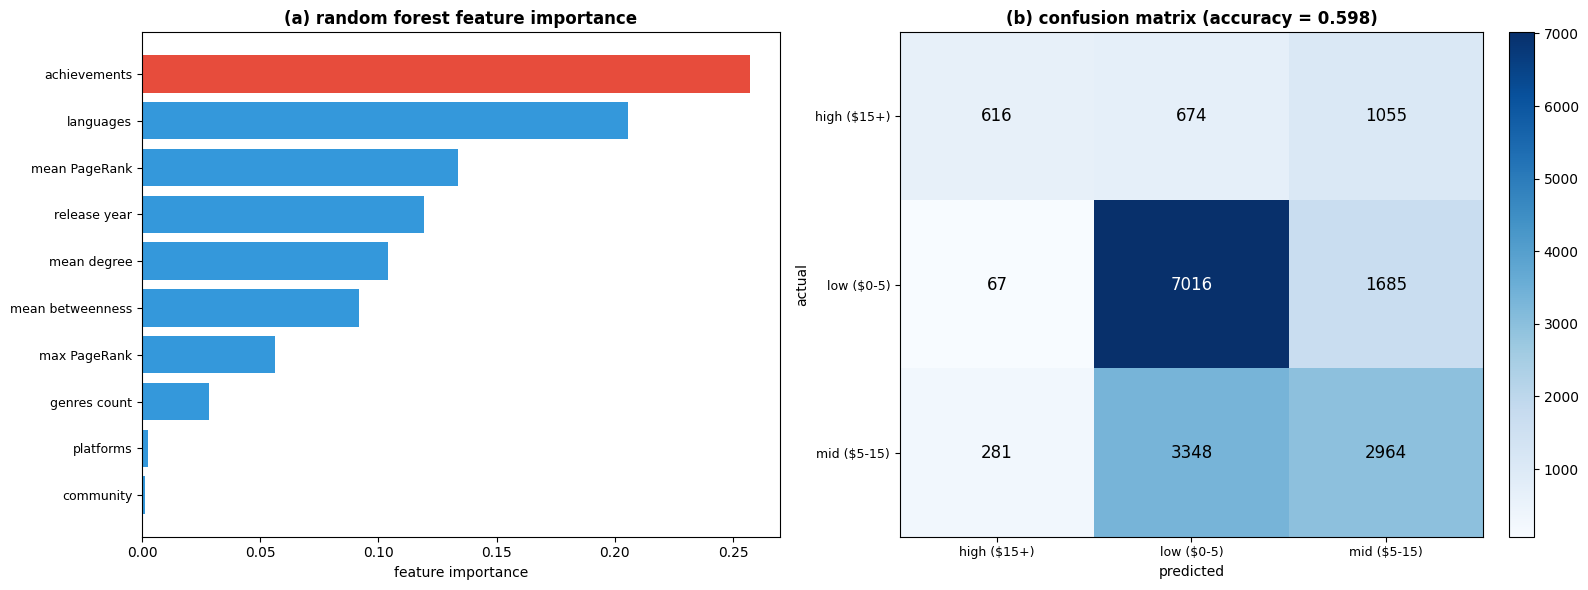

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
importances = rf.feature_importances_
sorted_idx = np.argsort(importances)
feature_labels = ['genres count', 'mean PageRank', 'max PageRank', 'mean degree',
                  'mean betweenness', 'community', 'platforms', 'achievements',
                  'languages', 'release year']
sorted_labels = [feature_labels[i] for i in sorted_idx]

colors_fi = ['#E74C3C' if i == sorted_idx[-1] else '#3498DB' for i in sorted_idx]
ax.barh(range(len(sorted_idx)), importances[sorted_idx], color=colors_fi)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels(sorted_labels, fontsize=9)
ax.set_xlabel('feature importance', fontsize=10)
ax.set_title('(a) random forest feature importance', fontsize=12, fontweight='bold')

ax = axes[1]
cm = confusion_matrix(y_test, y_pred_rf)
im = ax.imshow(cm, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, fontsize=9)
ax.set_yticks(range(len(le.classes_)))
ax.set_yticklabels(le.classes_, fontsize=9)
ax.set_xlabel('predicted', fontsize=10)
ax.set_ylabel('actual', fontsize=10)
ax.set_title(f'(b) confusion matrix (accuracy = {acc_rf:.3f})', fontsize=12, fontweight='bold')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm[i, j] > cm.max() * 0.5 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12, color=color)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/prediction_results.png", dpi=200, bbox_inches='tight')
plt.show()

## 13. model comparison

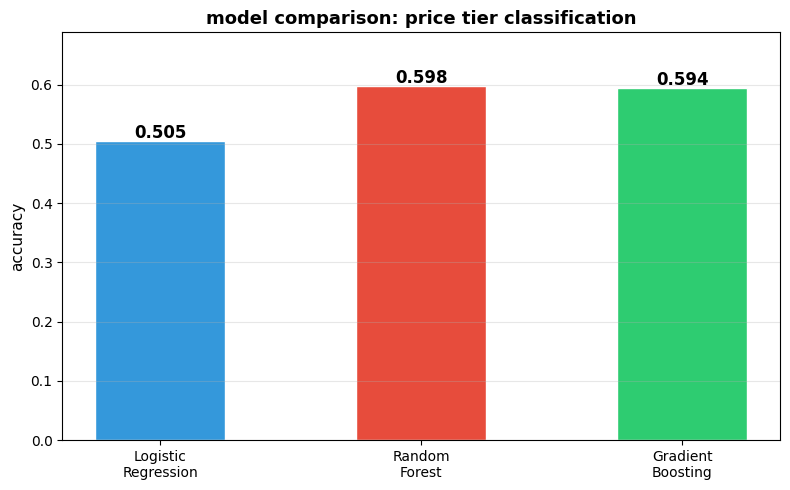

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))

models = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']
accs = [acc_lr, acc_rf, acc_gb]
colors_bar = ['#3498DB', '#E74C3C', '#2ECC71']

bars = ax.bar(models, accs, color=colors_bar, edgecolor='white', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('accuracy', fontsize=11)
ax.set_title('model comparison: price tier classification',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(accs) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/model_comparison.png", dpi=200, bbox_inches='tight')
plt.show()

## 14. summary

In [45]:
print("SUMMARY")
print()

print(f"dataset: steam dataset 2025 (239,664 applications)")
print(f"games in genre network: {app_genres_games['appid'].nunique():,}")
print(f"games in prediction task: {len(df):,}")
print(f"genre nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}")

print()
print("top 5 genres by pagerank:")
for i, row in metrics_df.head(5).iterrows():
    print(f"{i+1}. {row['genre']}: PR={row['pagerank']:.4f}, games={row['game_count']:,}")

print()
print(f"communities: {len(communities)}")
for i, comm in enumerate(communities):
    print(f"{i+1}: {sorted(comm)}")

print()
print("price tier prediction accuracy:")
print(f"logistic regression: {acc_lr:.4f}")
print(f"random forest:       {acc_rf:.4f}")
print(f"gradient boosting:   {acc_gb:.4f}")

print()

SUMMARY

dataset: steam dataset 2025 (239,664 applications)
games in genre network: 141,276
games in prediction task: 88,529
genre nodes: 18, edges: 125

top 5 genres by pagerank:
1. Indie: PR=0.1973, games=101,199
2. Casual: PR=0.1246, games=58,458
3. Adventure: PR=0.1245, games=59,014
4. Action: PR=0.1240, games=60,431
5. Simulation: PR=0.0746, games=30,321

communities: 5
1: ['Action', 'Adventure', 'Casual', 'Early Access', 'Indie', 'RPG', 'Simulation', 'Strategy']
2: ['Gore', 'Nudity', 'Sexual Content', 'Violent']
3: ['Free To Play', 'Massively Multiplayer']
4: ['Racing', 'Sports']
5: ['Episodic', 'Short']

price tier prediction accuracy:
logistic regression: 0.5046
random forest:       0.5984
gradient boosting:   0.5939

